In [ ]:
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean
# run.py
import glob, os; 
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import torch
from models.INSHAPE import MainFlow
import types
from scripts.trainer.train_loop import train, test, valid
from utils.util import set_seed, sliding_window, setup_optimizers, union_segments_scatter
import datetime
import math
from data_provider.UCR_data_factory import ucr_data_provider
import numpy as np
import wandb
from signal import signal, SIGPIPE, SIG_DFL
signal(SIGPIPE,SIG_DFL)

def get_latest_model_path(dataset_name, base_dir='../saved_models'):
    pattern = os.path.join(base_dir, dataset_name, 'best_Input_ROI_result_*.pt')
    model_files = glob.glob(pattern)
    
    if not model_files:
        raise FileNotFoundError(f"No model files found in {os.path.join(base_dir, dataset_name)}")
    latest_model = sorted(model_files)[-1]
    print(f"Loading latest model: {latest_model}")
    return latest_model

ucr_root = '../data/UCRConverted'

device='cuda:0'
dataset_name = 'CBF'

wandb.init(project="shapelet_discovery", name=dataset_name, config={
            # "lambda_1" : 0.005,
            "lambda_1" : 0.1,
            # "lambda_1" : 0.0005,
        }, reinit=True)

args = types.SimpleNamespace(
            seed=42,
            device=device,
            dataset=dataset_name, 
            data_root=ucr_root,
            save_path='save_models',
            data='ucr',
            task_name='classification',
            embed='fixed',
            freq='d',
            num_workers=0,
            seq_len=None,
            root_path=ucr_root,
            model_path = get_latest_model_path(dataset_name) 
        )

# 시드 설정
set_seed(args.seed)

train_loaders, val_loaders, test_loaders, param_dict = ucr_data_provider(args)
args.seq_len = param_dict['seq_len']

num_classes = param_dict['num_classes']
enc_in = param_dict['enc_in']

model = MainFlow(
    seq_len=args.seq_len,
    num_channels=enc_in,
    num_classes=num_classes,
    device=device,
    args=args,
).to(device)

train_loader = train_loaders[0]
val_loader = val_loaders[0]
test_loader = test_loaders[0]

def num_params(generator):
    return sum(p.numel() for p in generator if p.requires_grad == True)

print(f"lambda_1: {wandb.config.lambda_1}")

print(f"Dataset: {args.dataset}, Sequence Length: {args.seq_len}, Number of Channels: {enc_in}, Number of Classes: {num_classes}")
print(f"Train Data Size: {len(train_loader.dataset)}, "
    f"Valid Data Size: {len(val_loader.dataset)}, "
    f"Test Data Size: {len(test_loader.dataset)}")


state_dict = torch.load(args.model_path, map_location='cpu')
model.load_state_dict(state_dict)
model.eval()


test_acc, test_sel, test_Lc, test_sc = test(model, test_loader, is_uea=False ,tau = 1.3) 
print(f"Test Accuracy: {test_acc:.4f}, Selection Rate: {test_sel:.4f}, Lc : {test_Lc:.4f}")

In [2]:
lst = [i for i in test_loader]
test_data = lst[-1]
test_data_x, test_data_y = test_data[0], test_data[1]

In [3]:
pred, m, z_tilde, x_hat, logit, x, prob = model(test_data_x, padding_mask = None ,training=False , tau=1.3)

In [9]:
def reconstruct_sequence(data: torch.Tensor, stride: int) -> torch.Tensor:
    """
    windows: Tensor of shape (num_windows, window_size)
    stride: int, the stride used during sliding
    """
    window_size = data.shape[1]
    sequence = [data[0, :]]  

    for i in range(1, data.shape[0]):
        sequence.append(data[i, -stride:]) 

    return torch.cat(sequence)

def extract_shapelet_candidates_from_union(masked_X, eps=1e-8):
    """
    Extracts contiguous non-zero segments from a batch of time series.
    masked_X: Tensor of shape [B, 1, T] or [B, T].
    Returns:
        candidates: List of Tensors, each [L, 1]
        locations: List of tuples (batch_idx, channel_idx, start, end)
    """
    candidates = []
    locations = []
    
    # Ensure [B, 1, T] shape
    if masked_X.ndim == 2:
        masked_X = masked_X.unsqueeze(1)
        
    B, M, T = masked_X.shape
    
    # We use CPU copies for logic to avoid GPU sync overheads in loops,
    # but we will extract segments from the original (potentially GPU) tensor.
    masked_X_cpu = masked_X.detach().cpu()
    
    for b in range(B):
        for m in range(M):
            series_cpu = masked_X_cpu[b, m]
            
            # Create boolean mask of "active" regions
            mask = (series_cpu.abs() > eps).long()
            
            # Identify transitions: 0->1 (start), 1->0 (end)
            # Pad with 0s to handle segments starting at 0 or ending at T
            diffs = torch.diff(mask, prepend=torch.tensor([0]), append=torch.tensor([0]))
            
            starts = (diffs == 1).nonzero(as_tuple=False).flatten()
            ends = (diffs == -1).nonzero(as_tuple=False).flatten()
            
            # Extract segments
            for s, e in zip(starts, ends):
                length = e - s
                if length > 1: # Only keep segments longer than 1 point
                    s_idx = int(s)
                    e_idx = int(e)
                    
                    # Slice from original masked_X
                    seg = masked_X[b, m, s_idx:e_idx].clone()
                    
                    # Ensure [L, 1] shape
                    if seg.ndim == 1:
                        seg = seg.unsqueeze(1)
                        
                    candidates.append(seg)
                    locations.append((b, m, s_idx, e_idx))
                    
    return candidates, locations

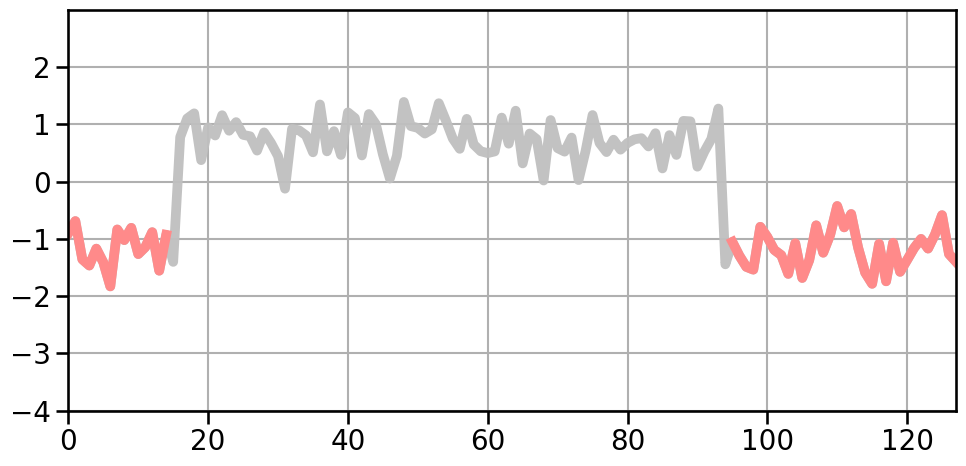

In [10]:
# --- Refactored Plotting Code (Aligned with Global Indexing) ---
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import numpy as np
import torch

# 1. Dataset & Index Selection
current_dataset = args.dataset
if current_dataset == 'MixedShapesRegularTrain':
    target_indices = [14]
elif current_dataset == 'EthanolLevel':
    target_indices = [2]
elif current_dataset == 'ECG5000':
    target_indices = [220]
else:
    print(f"Warning: Dataset {current_dataset} not specifically handled. Using index 0.")
    target_indices = [0]

# 2. Extract Data for Global Indices
# We iterate through the loader to find the specific samples
target_set = set(target_indices)
found_samples = {} 

model.eval()
global_idx_counter = 0

with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        if isinstance(batch, (list, tuple)):
            data, target = batch[0], batch[1]
        else:
            data, target = batch, None
            
        B = data.shape[0]
        batch_start = global_idx_counter
        batch_end = batch_start + B
        
        # 현재 배치에 target_indices가 포함되어 있는지 확인
        indices_in_batch = [idx for idx in target_indices if batch_start <= idx < batch_end]
        
        if indices_in_batch:
            data = data.to(next(model.parameters()).device)
            # Inference
            outputs = model(data, training=False, tau=1.3)
            z_tilde_batch = outputs[2] # Reconstructed
            pred_batch = outputs[0]    # Prediction
            
            # Extract Shapelets for the whole batch
            candidates_batch, locations_batch = extract_shapelet_candidates_from_union(z_tilde_batch)
            
            for global_idx in indices_in_batch:
                local_idx = global_idx - batch_start
                
                # Get Data
                orig_sample = data[local_idx].detach().cpu()
                z_tilde_sample = z_tilde_batch[local_idx].detach().cpu()
                
                # Get Shapelet Locations for this sample
                # locations_batch is list of (b, m, start, end) -> Filter for b == local_idx
                sample_locs = [(start, end) for (b, m, start, end) in locations_batch if b == local_idx]
                
                # Store info
                found_samples[global_idx] = {
                    'original': orig_sample,
                    'z_tilde': z_tilde_sample,
                    'locations': sample_locs,
                    'label': target[local_idx].item() if target is not None else None,
                    'pred': pred_batch[local_idx].argmax().item() if pred_batch is not None else None
                }
                
        global_idx_counter += B
        
        if len(found_samples) == len(target_indices):
            break

# 3. Plotting Loop
sns.set_context("talk")
mpl.rcParams["font.family"] = "DejaVu Sans"
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["xtick.labelsize"] = 20
mpl.rcParams["ytick.labelsize"] = 20

for real_idx in target_indices:
    if real_idx not in found_samples:
        print(f"Sample {real_idx} not found in dataset.")
        continue
        
    sample_info = found_samples[real_idx]
    
    # Data Preparation
    original_data = sample_info['original'].squeeze().numpy()
    z_tilde_data = sample_info['z_tilde'].squeeze().numpy()
    locations = sample_info['locations']
    
    x_len = len(original_data)
    x_vals = range(x_len)
    
    # Create Figure
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # Plot Original Data
    ax.plot(x_vals, original_data, 
            color="0.75", linewidth=7.0, alpha=0.95, label="Original")
    
    # Overlay Shapelets (Selected Region)
    has_plotted_shapelet = False
    for (start, end) in locations:
        safe_end = min(end, x_len)
        safe_start = max(0, start)
        if safe_start >= safe_end: continue

        x_range = range(safe_start, safe_end)
        y_values = z_tilde_data[safe_start:safe_end] 
        
        label = "Selected Region" if not has_plotted_shapelet else None
        
        ax.plot(x_range, y_values,
                color="#FF8A8A", linewidth=7.0, alpha=1, label=label)
        has_plotted_shapelet = True

    # Axes Settings
    ax.set_xlim(0, x_len - 1)
    ax.set_ylim(-4, 3)
    ax.grid(True)
    
    yticks = np.arange(-4, 3, 1)
    ax.set_yticks(yticks)
    
    # Save & Show
    plt.tight_layout()
    # save_path = f'./Ours_sample_{real_idx}.png'
    # plt.savefig(save_path, format="png", bbox_inches="tight")
    # print(f"Saved figure to {save_path}")
    plt.show()
    plt.close(fig)
   

In [11]:
from fastdtw import fastdtw
from scipy.spatial.distance import euclidean


def load_cluster_centers(path):
    # weights_only=False fixes "WeightsUnpickler" error on some torch versions
    try:
        obj = torch.load(path, map_location="cpu", weights_only=False)
    except:
        obj = torch.load(path, map_location="cpu")
        
    centers = None
    params = {}
    
    if isinstance(obj, list):
        centers = obj
    elif isinstance(obj, dict):
        if "params" in obj:
            params = obj["params"]
            
        if "cluster_centers" in obj:
            centers = obj["cluster_centers"]
        elif "global_shapelets" in obj:
            gs = obj["global_shapelets"]
            if isinstance(gs, dict):
                centers = list(gs.values())
            else:
                centers = gs
        elif "medoids" in obj and "global_shapelets" in obj:
            gs = obj["global_shapelets"]
            centers = list(gs.values()) if isinstance(gs, dict) else gs
            
    if centers is None:
        raise ValueError(f"Unrecognized format for cluster centers")
    
    centers = [c.detach().cpu() if isinstance(c, torch.Tensor) else torch.as_tensor(c) for c in centers]
    # Ensure (L, 1) or (L, F)
    centers = [c if c.ndim == 2 else c.unsqueeze(1) for c in centers]
    
    return centers, params

def match_shapelet(shapelet_query, cluster_centers, use_z_norm=False):
    best_idx, best_dist = -1, float("inf")
    
    q_np = shapelet_query.detach().cpu().numpy()
    if q_np.ndim == 1:
        q_np = q_np[:, None]
        
    if use_z_norm:
        # Inline basic z-norm 2d logic aligned with clustering
        # Treating each channel independently over time axis 0
        mu = q_np.mean(axis=0, keepdims=True)
        sd = q_np.std(axis=0, keepdims=True)
        sd[sd < 1e-8] = 1.0 # Avoid div by zero
        q_np = (q_np - mu) / sd

    # Flatten for fastdtw (L,)
    q_flat = q_np.flatten()
    
    for idx, center in enumerate(cluster_centers):
        if isinstance(center, torch.Tensor):
            c_np = center.numpy()
        else:
            c_np = np.array(center) # medoids might be numpy already
        c_np = c_np.flatten() # ensure 1D
        
        try:
            d, _ = fastdtw(q_flat, c_np, dist=2)
        except Exception:
            continue
            
        if d < best_dist:
            best_dist, best_idx = d, idx
    return best_idx, best_dist

# ─────────────────────────────────────────────
# 4) Revised Main Function: Support target_indices and Dynamic Center Loading
# ─────────────────────────────────────────────
def plot_replaced_shapelet(model, test_loader,
                           target_indices=None,  # e.g., [0, 10, 15]
                           centers_path=None,
                           max_segments_per_series=40
                           ):
    model.eval()
    
    # Auto-detect latest file if not found
    # Auto-detect latest file if not provided or doesn't exist
    if centers_path is None or not os.path.exists(centers_path):
        # Default directory
        dirname = "../shapelet_output/MedicalImages"
        if centers_path and not os.path.exists(os.path.dirname(centers_path)):
                # If user provided a path but dir doesn't exist, fallback to default
                pass
        elif centers_path:
                dirname = os.path.dirname(centers_path)
                
        if not os.path.exists(dirname):
                print(f"Error: Directory {dirname} not found.")
                return

        candidates = glob.glob(os.path.join(dirname, "global_shapelets_*.pt"))
        # Sort by modification time (newest first)
        candidates.sort(key=os.path.getmtime, reverse=True)
        
        if candidates:
            if centers_path:
                print(f"Warning: '{centers_path}' not found. Using latest: {candidates[0]}")
            else:
                print(f"Using latest shapelet file: {candidates[0]}")
            centers_path = candidates[0]
        else:
            print(f"Error: No shapelet files found in {dirname}")
            return
    cluster_centers, params = load_cluster_centers(centers_path)
    z_norm_segment = params.get("z_norm_segment", False)
    print(f"Loaded {len(cluster_centers)} centers from {os.path.basename(centers_path)}. z_norm_segment={z_norm_segment}")
    
    if target_indices is None:
        target_set = set(range(4))
    else:
        target_set = set(target_indices)
        
    global_idx = 0
    plotted_count = 0 
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(test_loader):
            if isinstance(batch, (list, tuple)):
                if len(batch) >= 2:
                    data, target = batch[:2]
                else:
                    data = batch[0]
            else:
                data = batch
            
            B = data.shape[0]
            batch_start_idx = global_idx
            
            batch_indices_to_process = []
            for b in range(B):
                if (batch_start_idx + b) in target_set:
                    batch_indices_to_process.append(b)
            
            if batch_indices_to_process:
                data_dev = data.to(next(model.parameters()).device)
                
                # Inference
                outputs = model(data_dev, training=False, tau=1.3)
                if len(outputs) >= 7:
                    z_tilde = outputs[2]
                    masked_X = z_tilde
                else:
                    z_tilde = outputs[2]
                    masked_X = z_tilde

                # Extract candidates from THIS batch
                candidates, locations = extract_shapelet_candidates_from_union(masked_X)
                # locations: list of (b, m, start, end)

                for b in batch_indices_to_process:
                    real_idx = batch_start_idx + b 
                    
                    orig_signal = data[b].detach().cpu()
                    if orig_signal.ndim > 1:
                        orig_signal = orig_signal.squeeze()
                        
                    # Reconstructed signal
                    z_tilde_sample = z_tilde[b].squeeze().detach().cpu()
                    
                    plt.figure(figsize=(12, 4))
                    plt.plot(orig_signal, label="Original", color='gray', alpha=0.5)
                    plt.plot(z_tilde_sample, label="Reconstructed (Masked Only)", color='blue', alpha=0.6, linestyle='--')
                    
                    # Overlay matched global shapelets
                    found_segments = 0
                    for i, (bb, mm, start, end) in enumerate(locations):
                        if bb != b:
                            continue
                        
                        found_segments += 1
                        if found_segments > max_segments_per_series:
                            break
                            
                        # Query shapelet (from reconstructed z_tilde)
                        shapelet = candidates[i]  # (L, 1) or (L,)
                        
                        # Find best match
                        center_idx, dist = match_shapelet(shapelet, cluster_centers, use_z_norm=z_norm_segment)
                        
                        if center_idx != -1:
                            best_center = cluster_centers[center_idx].squeeze().numpy()
                            # Overlay best center at location
                            x_vals = np.arange(start, end)
                            if len(best_center) != len(x_vals):
                                # Simple linspace interpolation for visualization
                                from scipy.interpolate import interp1d
                                old_x = np.linspace(0, 1, len(best_center))
                                new_x = np.linspace(0, 1, len(x_vals))
                                f = interp1d(old_x, best_center, kind='linear')
                                best_center_resampled = f(new_x)
                                plt.plot(x_vals, best_center_resampled, color='red', linewidth=2, alpha=0.8)
                            else:
                                plt.plot(x_vals, best_center, color='red', linewidth=2, alpha=0.8)
                    
                    plt.title(f"Sample {real_idx} (Batch {batch_idx}, Local {b}) - Red: Matched Global Shapelets")
                    plt.legend()
                    plt.show()
                    
                    plotted_count += 1
            
            global_idx += B
            if plotted_count >= len(target_set):
                break

Comparing with 15 global shapelets from global_shapelets_15c_20260120_141633.pt. Z-Norm: False


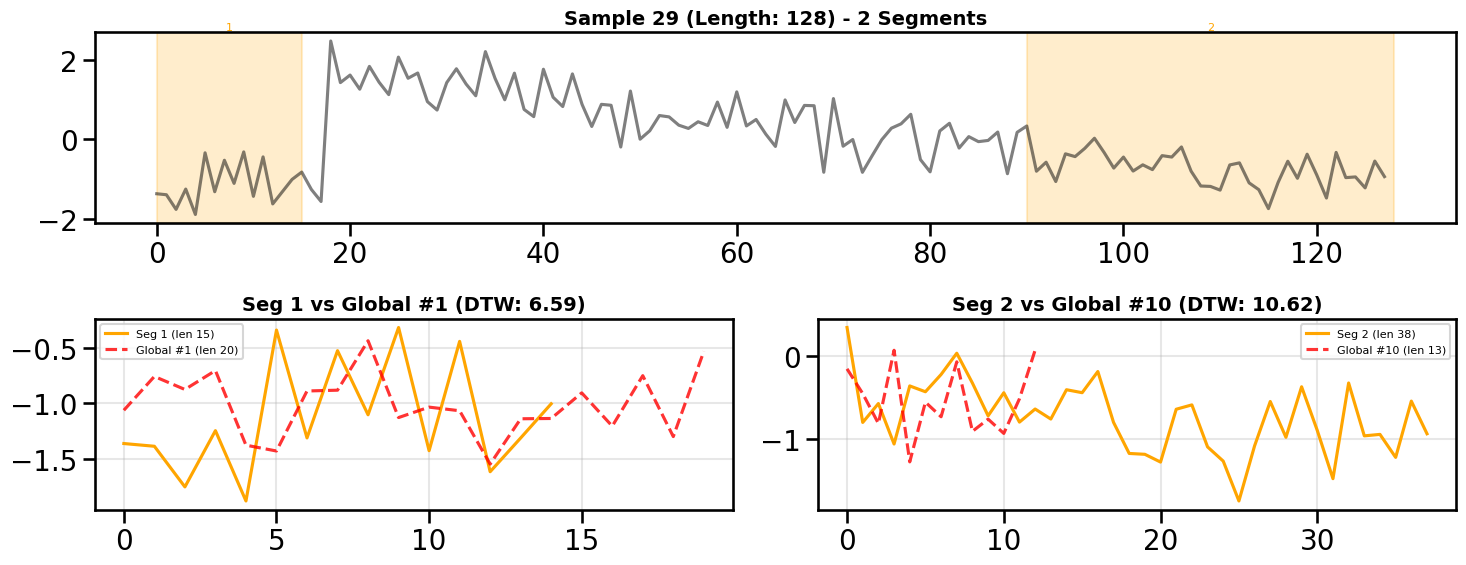

In [12]:
# ─────────────────────────────────────────────
# 2. Visualization: Sample vs Best Matching Global Shapelet
# ─────────────────────────────────────────────
def visualize_sample_with_closest_shapelet(
    model,
    data_loader,
    target_sample_id,
    centers_path=None
):
    model.eval()
    
    # Auto-detect latest
    # Auto-detect latest file if not provided or doesn't exist
    if centers_path is None or not os.path.exists(centers_path):
        # Default directory
        dirname = "..shapelet_output/MedicalImages"
        if centers_path and not os.path.exists(os.path.dirname(centers_path)):
                # If user provided a path but dir doesn't exist, fallback to default
                pass
        elif centers_path:
                dirname = os.path.dirname(centers_path)
                
        if not os.path.exists(dirname):
                print(f"Error: Directory {dirname} not found.")
                return

        candidates = glob.glob(os.path.join(dirname, "global_shapelets_*.pt"))
        # Sort by modification time (newest first)
        candidates.sort(key=os.path.getmtime, reverse=True)
        
        if candidates:
            if centers_path:
                print(f"Warning: '{centers_path}' not found. Using latest: {candidates[0]}")
            else:
                print(f"Using latest shapelet file: {candidates[0]}")
            centers_path = candidates[0]
        else:
            print(f"Error: No shapelet files found in {dirname}")
            return
    cluster_centers, params = load_cluster_centers(centers_path)
    z_norm_segment = params.get("z_norm_segment", False)
    print(f"Comparing with {len(cluster_centers)} global shapelets from {os.path.basename(centers_path)}. Z-Norm: {z_norm_segment}")

    found = False
    global_cnt = 0
    
    with torch.no_grad():
        for batch in data_loader:
            if isinstance(batch, (list, tuple)):
                data = batch[0]
            else:
                data = batch
            
            B = data.shape[0]
            
            if target_sample_id < global_cnt + B:
                local_idx = target_sample_id - global_cnt
                
                data_dev = data.to(next(model.parameters()).device)
                outputs = model(data_dev, training=False, tau=1.3)
                
                if len(outputs) >= 7:
                    z_tilde = outputs[2] 
                else:
                    z_tilde = outputs[2]
                
                masked_X = z_tilde
                
                # Extract
                candidates, locations = extract_shapelet_candidates_from_union(masked_X)
                
                # Filter for my sample
                my_segments = []
                for i, (b, m, start, end) in enumerate(locations):
                    if b == local_idx:
                        my_segments.append({
                            "segment": candidates[i], 
                            "start": start,
                            "end": end
                        })
                
                orig_ts = data[local_idx].detach().cpu().squeeze().numpy()
                
                # ─── Plot ───
                n_segs = len(my_segments)
                if n_segs == 0:
                    print(f"Sample {target_sample_id} has no detected shapelets.")
                    found = True
                    break

                # Grid layout
                cols = 2
                rows = (n_segs + cols - 1) // cols + 1 # +1 for main plot
                
                fig = plt.figure(figsize=(15, 3 * rows))
                gs = fig.add_gridspec(rows, cols)
                
                # Main Plot spanning all cols
                ax_main = fig.add_subplot(gs[0, :])
                ax_main.plot(orig_ts, label="Original Sample", color='black', alpha=0.5)
                ax_main.set_title(f"Sample {target_sample_id} (Length: {len(orig_ts)}) - {n_segs} Segments", fontsize=14, fontweight='bold')
                
                for i, seg_info in enumerate(my_segments):
                    s_loc = seg_info["start"]
                    e_loc = seg_info["end"]
                    segment_ts = seg_info["segment"].detach().cpu().numpy().flatten()
                    
                    # Highlight in main plot
                    ax_main.axvspan(s_loc, e_loc, color='orange', alpha=0.2)
                    ax_main.text((s_loc+e_loc)/2, ax_main.get_ylim()[1], str(i+1), ha='center', va='bottom', fontsize=8, color='orange')

                    # Subplot for this segment match
                    row = (i // cols) + 1
                    col = i % cols
                    ax_sub = fig.add_subplot(gs[row, col])
                    
                    # Match
                    best_idx, dist = match_shapelet(seg_info["segment"], cluster_centers, use_z_norm=z_norm_segment)
                    
                    # Align segment for display if z_norm was used
                    if z_norm_segment:
                        seg_disp = (segment_ts - segment_ts.mean()) / (segment_ts.std() + 1e-8)
                    else:
                        seg_disp = segment_ts
                        
                    ax_sub.plot(seg_disp, label=f"Seg {i+1} (len {len(segment_ts)})", color='orange')
                    
                    if best_idx != -1:
                        best_center = cluster_centers[best_idx].squeeze().numpy().flatten()
                        # Center supposedly already Z-normalized if z_norm_segment is True
                        ax_sub.plot(best_center, label=f"Global #{best_idx} (len {len(best_center)})", 
                                    color='red', linestyle='--', alpha=0.8)
                    
                    ax_sub.set_title(f"Seg {i+1} vs Global #{best_idx} (DTW: {dist:.2f})")
                    ax_sub.legend(fontsize=8)
                    ax_sub.grid(True, alpha=0.3)

                plt.tight_layout()
                plt.show()
                
                found = True
                break
            
            global_cnt += B
            
        if not found:
            print(f"Sample ID {target_sample_id} not found.")


path = max(glob.glob(f"../shapelet_output/{dataset_name}/global_shapelets_*.pt"), key=os.path.getmtime)

            
visualize_sample_with_closest_shapelet(model, test_loader, centers_path = path , target_sample_id=29)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

def analyze_shapelet_class_distribution(model, data_loader, cluster_centers, num_classes, z_norm_segment=False):
    """
    Analyzes which classes each global shapelet represents by matching candidates from the training set.
    Returns a matrix of counts [num_shapelets, num_classes].
    """
    print("Starting Shapelet Class Distribution Analysis...")
    model.eval()
    
    shapelet_class_counts = np.zeros((len(cluster_centers), num_classes))
    total_samples = 0
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(data_loader):
            if isinstance(batch, (list, tuple)):
                data, target = batch[0], batch[1]
            else:
                data, target = batch, None
            
            if target is None: continue
            
            data = data.to(next(model.parameters()).device)
            outputs = model(data, training=False, tau=1.3)
            masked_X = outputs[2]

            candidates, locations = extract_shapelet_candidates_from_union(masked_X)
            
            for i, (b, m, start, end) in enumerate(locations):
                if b >= len(target): continue
                label = int(target[b].item())
                shapelet_query = candidates[i]
                center_idx, dist = match_shapelet(shapelet_query, cluster_centers, use_z_norm=z_norm_segment)
                
                if center_idx != -1:
                    shapelet_class_counts[center_idx, label] += 1
            
            total_samples += data.size(0)
            if batch_idx % 10 == 0:
                print(f"Processed {total_samples} samples...")

    print(f"Analysis Complete. Processed {total_samples} samples.")
    return shapelet_class_counts

def analyze_shapelet_class_distribution(model, data_loader, cluster_centers, num_classes, z_norm_segment=False):
    """
    Analyzes which classes each global shapelet represents by matching candidates from the training set.
    Returns a matrix of counts [num_shapelets, num_classes].
    """
    print("Starting Shapelet Class Distribution Analysis...")
    model.eval()
    
    shapelet_class_counts = np.zeros((len(cluster_centers), num_classes))
    total_samples = 0
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(data_loader):
            if isinstance(batch, (list, tuple)):
                data, target = batch[0], batch[1]
            else:
                data, target = batch, None
            
            if target is None: continue
            
            data = data.to(next(model.parameters()).device)
            outputs = model(data, training=False, tau=1.3)
            masked_X = outputs[2]

            candidates, locations = extract_shapelet_candidates_from_union(masked_X)
            
            for i, (b, m, start, end) in enumerate(locations):
                if b >= len(target): continue
                label = int(target[b].item())
                shapelet_query = candidates[i]
                center_idx, dist = match_shapelet(shapelet_query, cluster_centers, use_z_norm=z_norm_segment)
                
                if center_idx != -1:
                    shapelet_class_counts[center_idx, label] += 1
            
            total_samples += data.size(0)
            if batch_idx % 10 == 0:
                print(f"Processed {total_samples} samples...")

    print(f"Analysis Complete. Processed {total_samples} samples.")
    return shapelet_class_counts

In [14]:
# 1. Load latest shapelets
shapelet_base_dir = "../shapelet_output"
dirname = os.path.join(shapelet_base_dir, dataset_name)

print(f"📂 Looking for shapelets in: {dirname}")
candidates_files = glob.glob(os.path.join(dirname, "global_shapelets_*.pt"))
candidates_files.sort(key=os.path.getmtime, reverse=True)

if not candidates_files:
    raise FileNotFoundError(f"No global shapelet files found in {dirname}")

centers_path = candidates_files[0]
print(f"✅ Using shapelets from: {centers_path}")
cluster_centers, params = load_cluster_centers(centers_path)
z_norm_segment = params.get("z_norm_segment", False)
print(f"Loaded {len(cluster_centers)} shapelets. Z-Norm: {z_norm_segment}")

# 2. Run Analysis
counts = analyze_shapelet_class_distribution(model, train_loader, cluster_centers, num_classes, z_norm_segment)

# 3. Precompute common values (시각화에서 재사용)
total_counts = counts.sum(axis=1).astype(int)
nonzero_mask = total_counts > 0
counts_filtered = counts[nonzero_mask]
total_counts_filtered = total_counts[nonzero_mask]
original_indices = np.where(nonzero_mask)[0]

# Probabilities
row_sums = counts_filtered.sum(axis=1, keepdims=True)
probs = np.divide(counts_filtered, row_sums, where=row_sums!=0)

# Store in a dict for easy access
analysis_result = {
    'counts': counts,                       # [num_shapelets, num_classes] raw counts
    'total_counts': total_counts,           # [num_shapelets] total per shapelet
    'counts_filtered': counts_filtered,     
    'total_counts_filtered': total_counts_filtered,
    'original_indices': original_indices,  
    'probs': probs,                        
    'num_classes': num_classes,
    'num_shapelets': len(cluster_centers),
    'dataset_name': dataset_name,
}

print(f"\n✅ Analysis Complete!")
print(f"   Total shapelets: {len(cluster_centers)}")
print(f"   Non-zero shapelets: {len(original_indices)}")
print(f"   Zero-count filtered: {(~nonzero_mask).sum()}")

📂 Looking for shapelets in: ../shapelet_output/CBF
✅ Using shapelets from: ../shapelet_output/CBF/global_shapelets_15c_20260120_141633.pt
Loaded 15 shapelets. Z-Norm: False
Starting Shapelet Class Distribution Analysis...
Processed 512 samples...
Analysis Complete. Processed 558 samples.

✅ Analysis Complete!
   Total shapelets: 15
   Non-zero shapelets: 14
   Zero-count filtered: 1


📊 Filtered to 6 shapelets (>= 10 total), 3 classes (>= 1 total)
   Valid classes: [0, 1, 2]
   Selected 4 unique shapelets across valid classes
   Shapelet IDs: [1, 2, 5, 10]
   Using dynamic figsize: (6, 9)


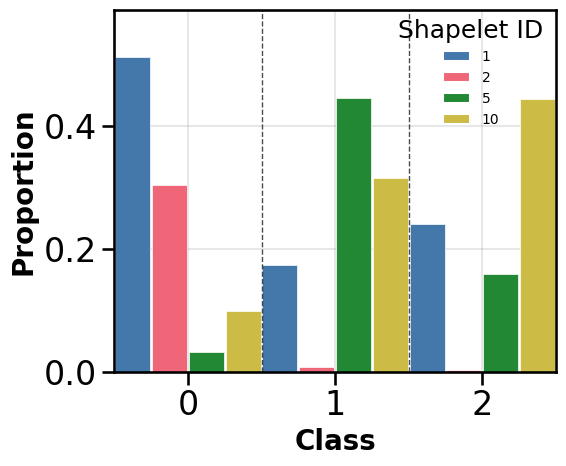

In [15]:
def plot_class_top_shapelets(result, top_n=5, min_class_count=1, min_shapelet_count=1, 
                             figsize=None, save_format=None, output_path=None, dpi=300,
                             target_classes=None):
    """
    Visualize the top N most frequent shapelets for each class.
    
    Args:
        top_n: Number of top shapelets to select per class.
        min_class_count: Minimum occurrence count for a class to be included.
        min_shapelet_count: Minimum occurrence count for a shapelet to be included globally.
        figsize: Figure dimensions (width, height). If None, automatically determined.
        save_format: File format to save ('pdf', 'png', or None to skip saving).
        output_path: Path for saving output. If None, automatically generated.
        dpi: Resolution for PNG output (default: 300).
        target_classes: List of specific classes to visualize (e.g., [0, 2, 4]). If None, includes all classes.
    """
    counts = result['counts']
    num_classes = result['num_classes']
    dataset_name = result['dataset_name']
    
    # Load explicit shapelet IDs
    shapelet_ids = result.get('shapelet_ids', list(range(len(counts))))
    
    # ========================================
    # 1. Global Shapelet Filtering
    # ========================================
    shapelet_totals = counts.sum(axis=1)
    shapelet_mask = shapelet_totals >= min_shapelet_count
    counts_filtered = counts[shapelet_mask]
    shapelet_indices = np.where(shapelet_mask)[0]
    
    filtered_shapelet_ids = [shapelet_ids[idx] for idx in shapelet_indices]
    
    if len(shapelet_indices) == 0:
        print(f"No shapelets with total count >= {min_shapelet_count}.")
        return None, None
    
    # ========================================
    # 2. Class Filtering
    # ========================================
    class_totals = counts_filtered.sum(axis=0)
    class_mask = class_totals >= min_class_count
    valid_classes = np.where(class_mask)[0]
    
    if len(valid_classes) == 0:
        print(f"No classes with total count >= {min_class_count}.")
        return None, None
    
    # ========================================
    # 2.5. Target Class Filtering
    # ========================================
    if target_classes is not None:
        target_classes_set = set(target_classes)
        valid_classes_mask = np.array([c in target_classes_set for c in valid_classes])
        valid_classes = valid_classes[valid_classes_mask]
        
        if len(valid_classes) == 0:
            print(f"⚠️ No valid classes found in target_classes={target_classes}")
            return None, None
        
        print(f"🎯 Plotting only target classes: {valid_classes.tolist()}")
    
    counts_filtered = counts_filtered[:, class_mask]
    
    if target_classes is not None:
        counts_filtered = counts_filtered[:, valid_classes_mask]
    
    print(f"📊 Filtered to {len(shapelet_indices)} shapelets (>= {min_shapelet_count} total), "
          f"{len(valid_classes)} classes (>= {min_class_count} total)")
    print(f"   Valid classes: {valid_classes.tolist()}")
    
    # ========================================
    # 3. Select top N shapelets for each class (get the set of all shapelets)
    # ========================================
    selected_shapelets = set()
    class_top_shapelets = {}
    
    for i, c in enumerate(valid_classes):
        class_counts = counts_filtered[:, i]
        
        if class_counts.sum() == 0:
            class_top_shapelets[c] = []
            continue
        
        # 해당 클래스에서 count 기준 top N 선택
        top_n_positions = np.argsort(class_counts)[::-1][:top_n]
        
        # 해당 클래스의 top N shapelet ID 수집
        for pos in top_n_positions:
            shapelet_id = filtered_shapelet_ids[pos]
            selected_shapelets.add(shapelet_id)
    
    # ========================================
    # 4. List of all selected shapelet IDs
    # ========================================
    selected_shapelets = sorted(list(selected_shapelets))
    
    if len(selected_shapelets) == 0:
        print(f"No shapelets selected.")
        return None, None
    
    print(f"   Selected {len(selected_shapelets)} unique shapelets across valid classes")
    print(f"   Shapelet IDs: {selected_shapelets}")
    
    # ========================================
    # 4.5. Calculate frequency of all selected shapelets for each class
    # ========================================
    # Find indices of selected_shapelets in filtered_shapelet_ids
    shapelet_id_to_filtered_idx = {sid: idx for idx, sid in enumerate(filtered_shapelet_ids)}
    
    for i, c in enumerate(valid_classes):
        class_counts = counts_filtered[:, i]
        class_total = class_counts.sum()
        
        # Calculate frequency of all selected shapelets
        all_freqs = []
        for sid in selected_shapelets:
            if sid in shapelet_id_to_filtered_idx:
                filtered_idx = shapelet_id_to_filtered_idx[sid]
                freq = class_counts[filtered_idx] / class_total if class_total > 0 else 0
                all_freqs.append((sid, freq))
            else:
                all_freqs.append((sid, 0.0))
        
        class_top_shapelets[c] = all_freqs
    
    # ========================================
    # 5. Dynamic figsize calculation
    # ========================================
    if figsize is None:
        width = min(500, len(valid_classes) * 2)
        print(f"   Using dynamic figsize: ({width}, 9)")
        height = 5
        figsize = (width, height)
    
    # ========================================
    # 6. Tol Bright color palette
    # ========================================
    tol_bright = [
        "#4477AA", "#EE6677", "#228833", "#CCBB44",
        "#66CCEE", "#AA3377", "#BBBBBB",
        "#000000", "#FFAABB", "#77AADD",
        "#99DDFF", "#44AA99"
    ]
    
    shapelet_to_color = {}
    for i, sid in enumerate(selected_shapelets):
        color_idx = i % len(tol_bright)
        shapelet_to_color[sid] = tol_bright[color_idx]
    
    # ========================================
    # 7. Visualization (all selected shapelets)
    # ========================================
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot all selected shapelets for each class
    n_shapelets = len(selected_shapelets)
    bar_width = 1 / n_shapelets
    
    for i, c in enumerate(valid_classes):
        all_shapelets = class_top_shapelets[c]
        
        for j, (shapelet_id, freq) in enumerate(all_shapelets):
            offset = (j - (n_shapelets - 1) / 2) * bar_width
            ax.bar(i + offset, freq, bar_width * 0.95,
                   color=shapelet_to_color[shapelet_id],
                   edgecolor='white', linewidth=0.5)
    
    # ========================================
    # 8. X-axis label settings
    # ========================================
    x = np.arange(len(valid_classes))
    ax.set_xticks(x)
    ax.set_xticklabels([f"{c}" for c in valid_classes])
    ax.set_xlim(-0.5, len(valid_classes) - 0.5)

    ax.tick_params(axis='both', which='major', labelsize=24)
    # ========================================
    # 9. Y-axis range
    # ========================================
    max_freq = max([freq for tops in class_top_shapelets.values() 
                    for _, freq in tops], default=0)
    ax.set_ylim(0, max_freq * 1.15)
    
    # ========================================
    # 10. Title and labels
    # ========================================
    ax.set_xlabel("Class", fontsize=20, fontweight='bold')
    ax.set_ylabel("Proportion", fontsize=20, fontweight='bold')
    
    # ========================================
    # 11. Legend
    # ========================================
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=shapelet_to_color[sid], 
                            edgecolor='white', label=f'{sid}')
                      for sid in selected_shapelets]
    ax.legend(handles=legend_elements, 
             title="Shapelet ID",
             loc='upper right',
             bbox_to_anchor=(1.0, 1.01),
             fontsize=10,
             frameon=False,
             handlelength=2)
    
    # ========================================
    # 12. Add grid
    # ========================================
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)
    # Add vertical lines to separate classes
    for i in range(1, len(valid_classes)):
        ax.axvline(x=i - 0.5, color='black', linestyle='--', linewidth=1, alpha=0.7)
        
    plt.tight_layout()
    
    # ========================================
    # 13. Save file
    # ========================================
    if save_format is not None:
        if save_format.lower() not in ['pdf', 'png']:
            print(f"⚠️  Unknown format '{save_format}'. Supported: 'pdf', 'png'")
        else:
            if output_path is None:
                output_path = f"./{dataset_name}_top{top_n}_shapelets.{save_format.lower()}"
            
            if save_format.lower() == 'png':
                plt.savefig(output_path, format="png", bbox_inches="tight", dpi=dpi)
            else:
                plt.savefig(output_path, format="pdf", bbox_inches="tight")
            
            print(f"💾 Saved to: {output_path}")
    
    plt.show()
    plt.close(fig)
    
    return selected_shapelets, class_top_shapelets

selected_ids, class_tops = plot_class_top_shapelets(
    analysis_result, 
    top_n=3,
    min_class_count=1,
    min_shapelet_count=10,
)

In [16]:
import pandas as pd
import numpy as np

# 1. Probability Calculation (preventing division by zero)
row_sums = counts.sum(axis=1, keepdims=True)

# Initialize probs with zeros to avoid garbage values
probs = np.zeros_like(counts, dtype=float)
np.divide(counts, row_sums, out=probs, where=row_sums!=0)

# 2. Filter out shapelets with zero counts (never matched)
nonzero_mask = row_sums.flatten() > 0
probs_filtered = probs[nonzero_mask]
original_indices = np.where(nonzero_mask)[0]

# 3. DataFrame Creation (only for matched shapelets)
df = pd.DataFrame(probs_filtered, 
                  index=original_indices,
                  columns=[f"Class {i}" for i in range(num_classes)])
df.index.name = "Global Shapelet ID"

# 4. Add Dominant Class and Max Probability columns
df["Dominant Class"] = np.argmax(probs_filtered, axis=1)
df["Max Probability"] = np.max(probs_filtered, axis=1)

# 5. Sorting and Display
df_sorted = df.sort_values(by=["Dominant Class", "Max Probability"], ascending=[True, False])

display(df_sorted.style.background_gradient(cmap='Greens', subset=[f"Class {i}" for i in range(num_classes)])
       .format("{:.2%}")
       .format("{:.0f}", subset=["Dominant Class"]))

,Class 0,Class 1,Class 2,Dominant Class,Max Probability
Global Shapelet ID,,,,,
2,96.49%,2.63%,0.88%,0,96.49%
1,55.56%,18.02%,26.43%,0,55.56%
6,0.00%,100.00%,0.00%,1,100.00%
8,0.00%,100.00%,0.00%,1,100.00%
9,0.00%,100.00%,0.00%,1,100.00%
5,5.36%,68.75%,25.89%,1,68.75%
12,0.00%,0.00%,100.00%,2,100.00%
13,0.00%,0.00%,100.00%,2,100.00%
14,0.00%,0.00%,100.00%,2,100.00%


In [17]:
# Check total matches per shapelet
total_matches = counts.sum(axis=1)
dead_shapelets = np.where(total_matches == 0)[0]

print(f"Total Shapelets: {len(total_matches)}")
print(f"Dead Shapelets (0 matches): {len(dead_shapelets)}")
print(f"Dead Shapelet IDs: {dead_shapelets}")

Total Shapelets: 15
Dead Shapelets (0 matches): 1
Dead Shapelet IDs: [7]
